In [18]:
import pandas as pd
import seaborn as sns

In [19]:
df=pd.read_csv('/content/DATA (1).csv')

In [20]:
df

,STUDENT ID,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,...,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,...,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,...,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,...,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,...,2,1,2,2,2,1,2,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,STUDENT141,2,1,2,3,1,1,2,1,1,...,1,1,2,1,2,1,3,3,9,5
141,STUDENT142,1,1,2,4,2,2,2,1,4,...,1,1,3,2,2,1,5,3,9,5
142,STUDENT143,1,1,1,4,2,2,2,1,1,...,1,1,3,3,2,1,4,3,9,1
143,STUDENT144,2,1,2,4,1,1,1,5,2,...,2,1,2,1,2,1,5,3,9,4


<Axes: xlabel='GRADE', ylabel='count'>

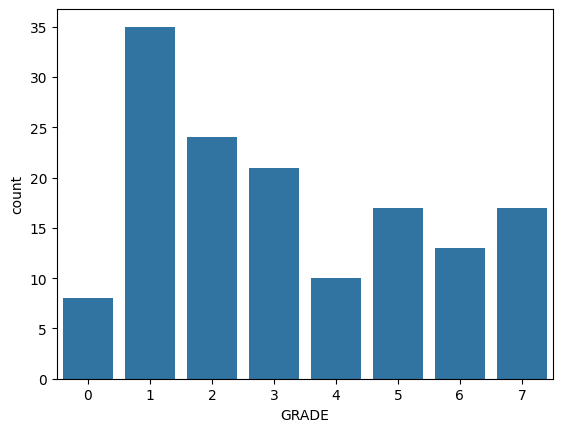

In [7]:
sns.countplot(x='GRADE',data=df) # distribution of student grades to visualize grade frequencies. GRADE has 8 unique values (ranging from 0 to 7).

In [8]:
df['COURSE ID'].value_counts() #no. of students enrolled per course

,count
COURSE ID,
1,66
9,21
7,15
8,14
3,8
6,8
5,7
4,4
2,2


<Axes: xlabel='COURSE ID', ylabel='count'>

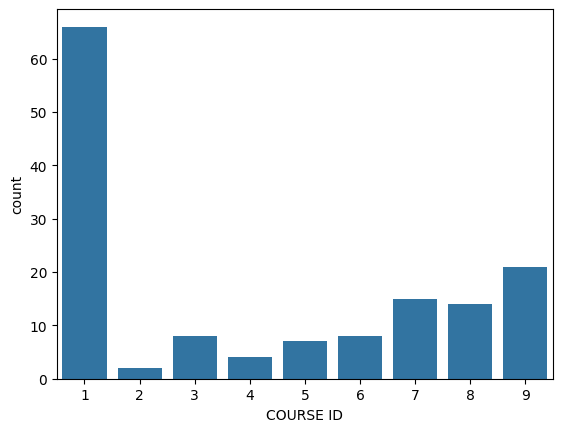

In [9]:
sns.countplot(x='COURSE ID', data=df)

In [10]:
df.iloc[:, 1:31].mean() #average response for each question

,0
1,1.620690
2,1.600000
3,1.944828
4,3.572414
5,1.662069
6,1.600000
7,1.579310
8,1.627586
9,1.620690
10,1.731034


In [11]:
df.iloc[:, 1:31].mean().idxmax() #question that has the highest average score

'4'

In [12]:
df.iloc[:, 1:31].var().idxmax() #question that has the highest variance (disagreement)

'13'

In [14]:
df['average'] = df.iloc[:, 1:31].mean(axis=1) #distribution of average student scores per course

<Axes: xlabel='COURSE ID', ylabel='average'>

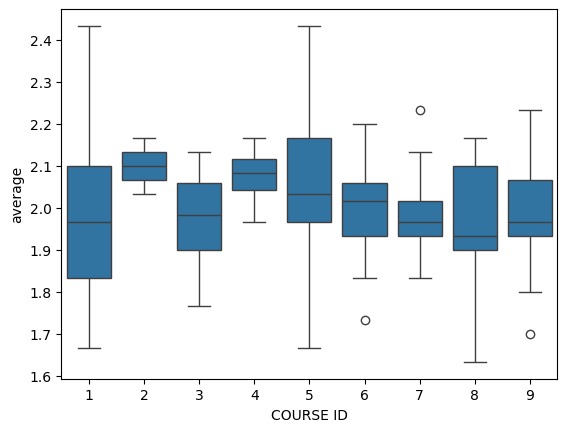

In [15]:
sns.boxplot(x='COURSE ID', y='average', data=df)

In [16]:
df.groupby('COURSE ID')['GRADE'].mean()

,GRADE
COURSE ID,
1,2.287879
2,3.000000
3,6.125000
4,4.500000
5,5.285714
6,5.875000
7,6.333333
8,1.357143
9,2.190476


In [ ]:
# course has the highest average grade - Course: 3

<Axes: xlabel='average', ylabel='GRADE'>

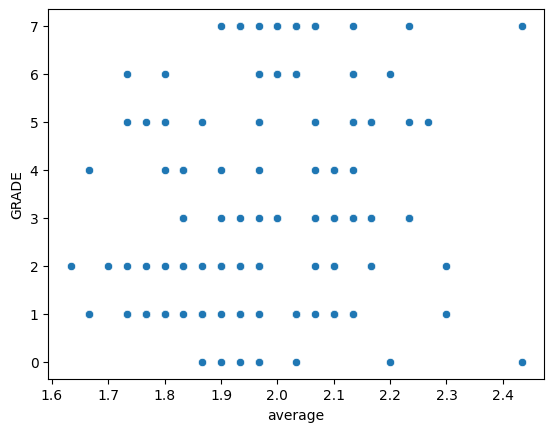

In [17]:
sns.scatterplot(x='average', y='GRADE', data=df) # correlation between average score and grade

<Axes: >

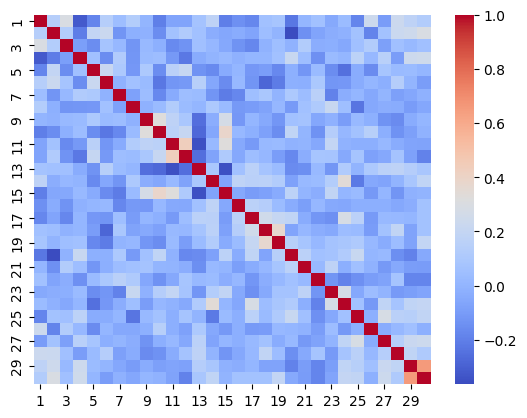

In [21]:
sns.heatmap(df.iloc[:, 1:31].corr(), cmap='coolwarm') # questions that are highly correlated

In [ ]:
# most questions are weakly correlated (correlation close to 0) -Light to medium blue
# light red/orange off-diagonal blocks
→ Indicates a few question pairs have moderate positive correlation (e.g., 0.4 to 0.6)
# Slight patches of darker blue (negative correlations)
→ A few question pairs might be inversely related, though the values seem weak (not close to -1).

In [22]:
df.iloc[:, 1:31].corrwith(df['GRADE']) # questions that are strongly correlated with final grade

,0
1,-0.095251
2,0.335533
3,0.104821
4,0.023963
5,0.167445
6,-0.062993
7,-0.051778
8,-0.166352
9,-0.156289
10,0.023683


In [27]:
df.iloc[:, 1:31].apply(lambda x: (x==x.max()).sum(), axis=1) #students who scored the maximum on most questions

,0
0,1
1,6
2,1
3,1
4,2
...,...
140,1
141,2
142,5
143,2


<Axes: >

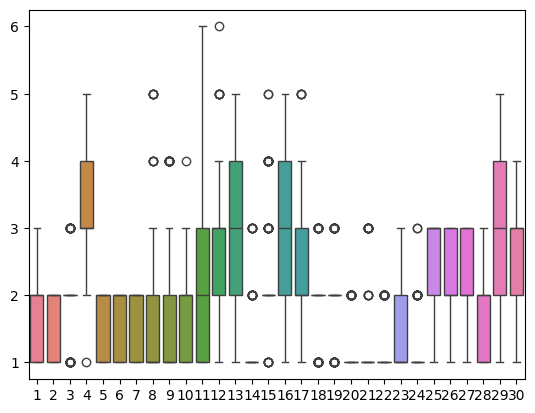

In [28]:
sns.boxplot(data=df.iloc[:, 1:31]) # Existence of outliers

In [ ]:
# 🟣 Dots above whiskers	These are outliers, where students responded significantly higher than typical. Example: Questions 9, 13, 14, 15, 16 have multiple outliers.
# Blue Dots below whiskers	These indicate low outliers - very less
# ⬛ Narrow boxes (e.g., Q2, Q6–9, Q22)	These questions had low response variability, i.e., most students answered similarly.
# Tall boxes and whiskers (e.g., Q13, Q15, Q30)	These questions had high variability, showing a spread in opinions.

In [30]:
pd.crosstab(df['COURSE ID'], df['GRADE']) #Is data balanced across grades and courses?

GRADE,0,1,2,3,4,5,6,7
COURSE ID,,,,,,,,
1,3,23,15,12,3,10,0,0
2,0,1,0,0,0,1,0,0
3,0,0,0,0,0,2,3,3
4,0,0,0,1,2,0,0,1
5,0,0,0,1,2,1,0,3
6,0,0,0,0,1,0,6,1
7,0,0,0,1,0,1,4,9
8,1,7,6,0,0,0,0,0
9,4,4,3,6,2,2,0,0


In [ ]:
# 🧍‍♂️ Unequal students per course.	Course 1 has 66 students (sum of its row), while Courses 2–8 have very few (some ≤ 5).
# 🎓 Grade imbalance within courses.	For example, Course 1 has 23 students in one grade, but 0 in others — clearly skewed.
# 📉 Some courses are underrepresented.	Courses 2–6 have very sparse data, which may not support reliable analysis or modeling.